# Ray tracing simulation # 

In [13]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


In [186]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')
num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())

tx = Transmitter("tx", [0, -2, 1.5])
# tx = Transmitter("tx", [-4, 8, 1])
scene.add(tx)

# Rx positions
x1, y1 = -7, 8
x2, y2 = 0, 8
x3, y3 = 7, 8
x4, y4 = 9, 0
x5, y5 = -9, 0
x6, y6 = -7, -8
x7, y7 = 0, -8
x8, y8 = 7, -8

RX_positions = [[x1, y1], [x2, y2], [x3, y3], [x4, y4], [x5, y5], [x6, y6], [x7, y7], [x8, y8]]

rx1 = Receiver("rx", [x1, y1, 1.5])
rx2 = Receiver("rx2", [x2, y2, 1.5])
rx3 = Receiver("rx3", [x3, y3, 1.5])
rx4 = Receiver("rx4", [x4, y4, 1.5])
rx5 = Receiver("rx5", [x5, y5, 1.5])
rx6 = Receiver("rx6", [x6, y6, 1.5])
rx7 = Receiver("rx7", [x7, y7, 1.5])
rx8 = Receiver("rx8", [x8, y8, 1.5])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)
scene.add(rx6)
scene.add(rx7)
scene.add(rx8)

scene.preview()

no-name-6      itu-concrete
elm__7         itu-glass
Directivity [dB]: 1.76
Gain [dB]: 1.76
Efficiency [%]: 1e+02
([1.49999], [1.5], [1.00001])


### Paths computations ###

In [187]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.5 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [188]:
scene.preview(paths=paths)

0.001
1e-12
(12,)


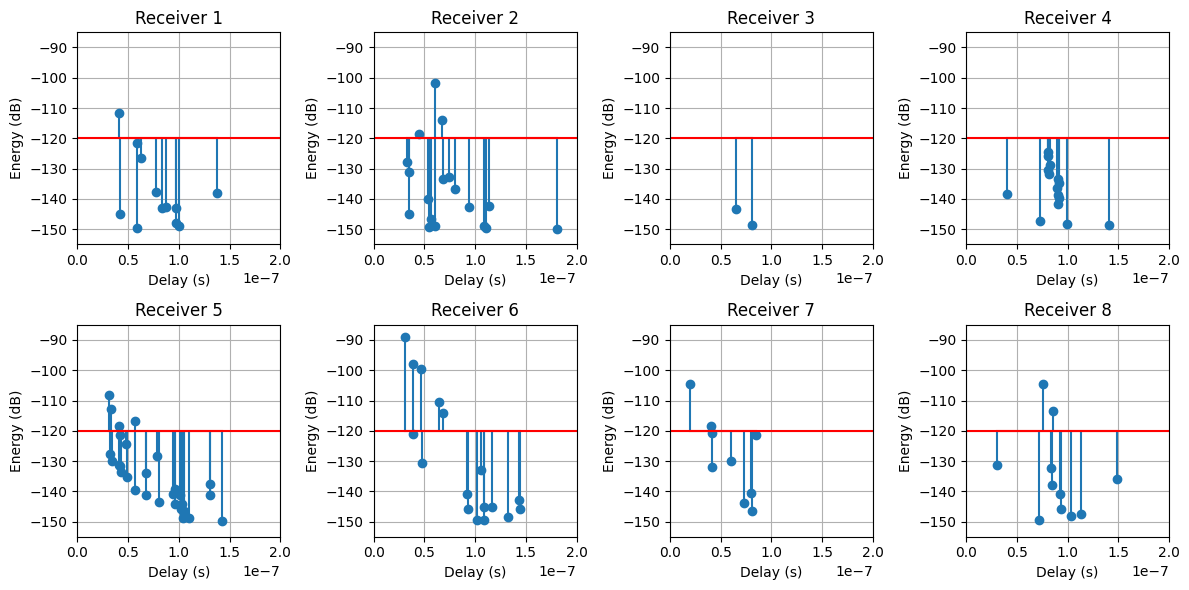

In [190]:
importlib.reload(util)
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles, array=True)



# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(8)]
energies = [magnitudes[i]**2 for i in range(8)]

# Power transmitted and receiver sensitivity
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000  # Convert dBm to Watts
print(P_TX_lin)

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000  # Convert dBm to Watts
print(S_RX_lin)

energies = [energies[i] * P_TX_lin for i in range(8)]


# Filter paths too weak
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(8):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask].reshape(num_rx_ant, -1)
    tau[i] = tau[i][mask[0]]
    angles[i] = angles[i][mask[0]]
    magnitudes[i] = magnitudes[i][mask].reshape(num_rx_ant, -1)
    energies[i] = energies[i][mask].reshape(num_rx_ant, -1)
    if i == 0:
        print(energies[i][0].shape)


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 2e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

In [53]:
# System parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs


(8, 4, 21)
2.9612136e-11
3.046574523989072e-11


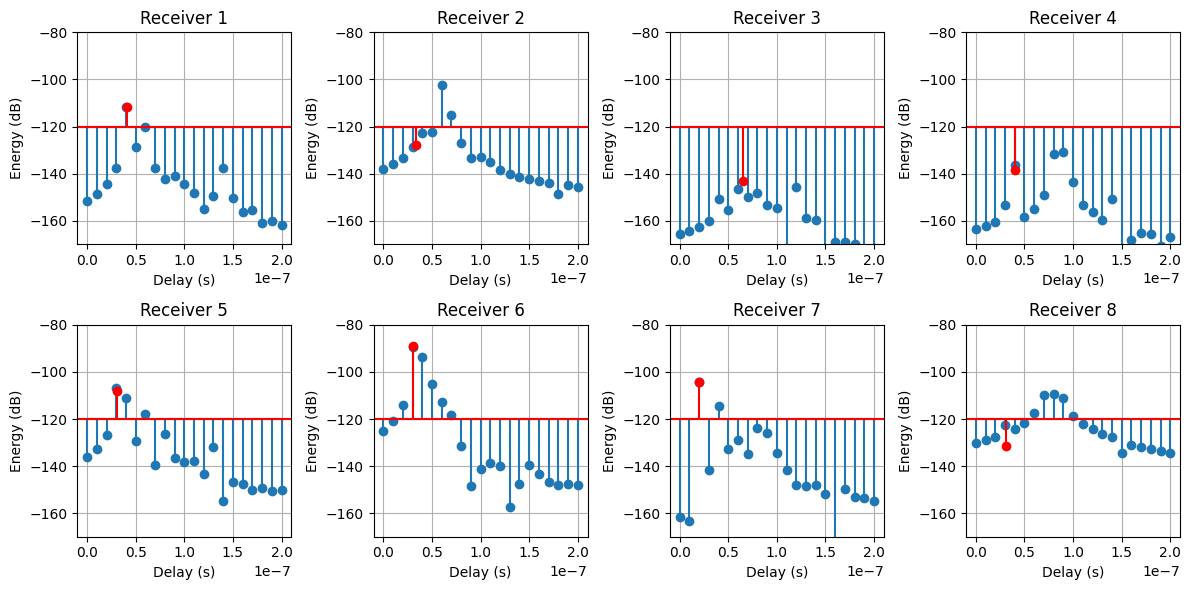

In [154]:
# Channel impulse response of the path
l_min, l_max = 0, 20
B = 100e6
t = np.arange(l_min, l_max+1) / B
taps = paths.taps(bandwidth=B, l_min=l_min, l_max=l_max, normalize_delays=False)
taps_re, taps_im = taps[0], taps[1]
taps_re = taps_re.numpy().reshape(taps_re.shape[0], num_rx_ant, -1)
taps_im = taps_im.numpy().reshape(taps_im.shape[0], num_rx_ant, -1)
taps_lin = taps_re + 1j * taps_im
taps_mag = np.sqrt(taps_re**2 + taps_im**2)
taps_mag = taps_mag
print(taps_mag.shape)

taps_energy = taps_mag ** 2 * P_TX_lin

print(np.sum(taps_energy[0]))
print(np.sum(energies[0]))


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(t, 10*np.log10(taps_energy[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.stem(tau[i][0], 10*np.log10(energies[i][0][0]), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='ro', label='Path Energies')
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim((l_min-1)/B, (l_max+1)/B)
    plt.ylim(-170, -80)
    plt.grid()
plt.tight_layout()

In [205]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)


fft_size = 256
RX_idx = 7
music_spectrum, music_tau, music_angles, estimated_channel = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=5, h_hat_debug=None)
# music_a, music_taus = mp.MUSIC_taps_time(music_spectrum, music_tau, B/fft_size, estimated_channel)


R shape: (408, 408)
Optimal number of paths: 6
P shape: (100, 40)


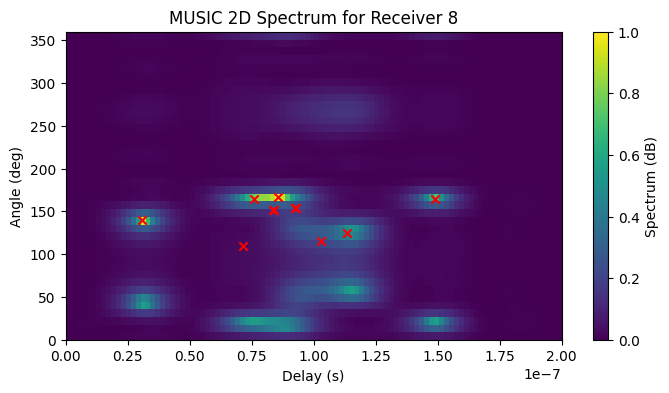

In [ ]:
plt.figure(figsize=(8, 4))
plt.imshow(10*np.log10(music_spectrum.T), extent=(music_tau[0], music_tau[-1], music_angles[0]*180/np.pi, music_angles[-1]*180/np.pi), aspect='auto', origin='lower')
plt.scatter(tau[RX_idx], angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
plt.title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Angle (deg)")
plt.colorbar(label='Spectrum (dB)')
plt.show()

Number of iterations: 100
P_TX_lin: 0.001 W, No: 4.002e-05 W
No : 4.002e-05
Optimal number of paths: 6
Optimal number of paths: 6


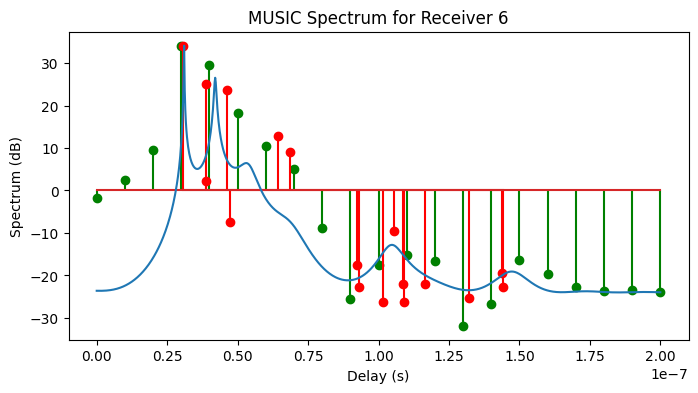

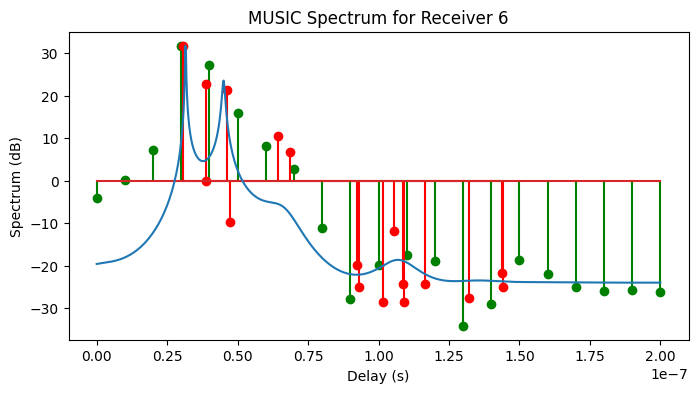

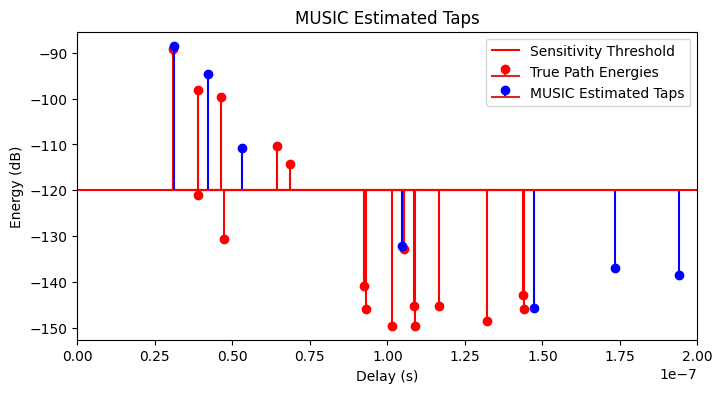

In [ ]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)


fft_size = 512
RX_idx = 0
music_spectrum1, music_tau1, estimated_channel1 = mp.MUSIC_spectrum_time(a[RX_idx], tau[RX_idx], B, T=1e-5, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=1, h_hat_debug=None)
music_a, music_taus = mp.MUSIC_taps_time(music_spectrum1, music_tau1, B/fft_size, estimated_channel1)
plt.figure(figsize=(8, 4))
plt.stem(t, 10*np.log10(taps_energy[RX_idx]*np.max(music_spectrum1)/np.max(taps_energy[RX_idx])), markerfmt='go', linefmt='g-', label='Taps Energy')
plt.stem(tau[RX_idx], 10*np.log10(energies[RX_idx]*np.max(music_spectrum1)/np.max(energies[RX_idx])), markerfmt='ro', linefmt='r-', label='True Path Energies')
plt.plot(music_tau1, 10*np.log10(music_spectrum1), label='MUSIC Spectrum')
plt.title(f"MUSIC Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Spectrum (dB)")
plt.show()


plt.figure(figsize=(8, 4))
plt.stem(tau[RX_idx], 10*np.log10(energies[RX_idx]), bottom=10*np.log10(S_RX_lin), markerfmt='ro', linefmt='r-', label='True Path Energies')
plt.stem(music_taus, 10*np.log10(np.abs(music_a)**2*P_TX_lin), bottom=10*np.log10(S_RX_lin), markerfmt='bo', linefmt='b-', label='MUSIC Estimated Taps')
plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
plt.legend()
plt.title("MUSIC Estimated Taps")
plt.xlabel("Delay (s)")
plt.ylabel("Energy (dB)")
plt.xlim(0, 2e-7)
plt.show()

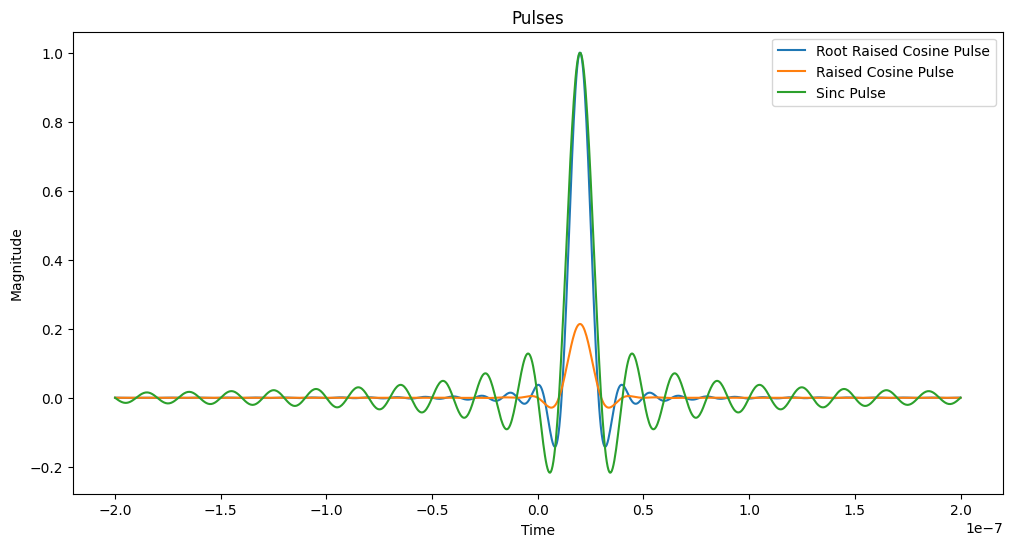

In [9]:
t_plot = np.linspace(-2e-7, 2e-7, 1000)
tau_plot = 2e-8
plt.figure(figsize=(12, 6))
plt.plot(t_plot, com.RRC(t_plot, tau_plot, B, alpha=0.5), label='Root Raised Cosine Pulse')
plt.plot(t_plot, com.RC(t_plot, tau_plot, B, alpha=0.5), label='Raised Cosine Pulse')
plt.plot(t_plot, np.sinc((t_plot - tau_plot) * B), label='Sinc Pulse')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.title('Pulses')
plt.legend()
plt.show()



c:\Users\louis\OneDrive\Documents\Memoire\RayTracing\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\louis\OneDrive\Documents\Memoire\RayTracing\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


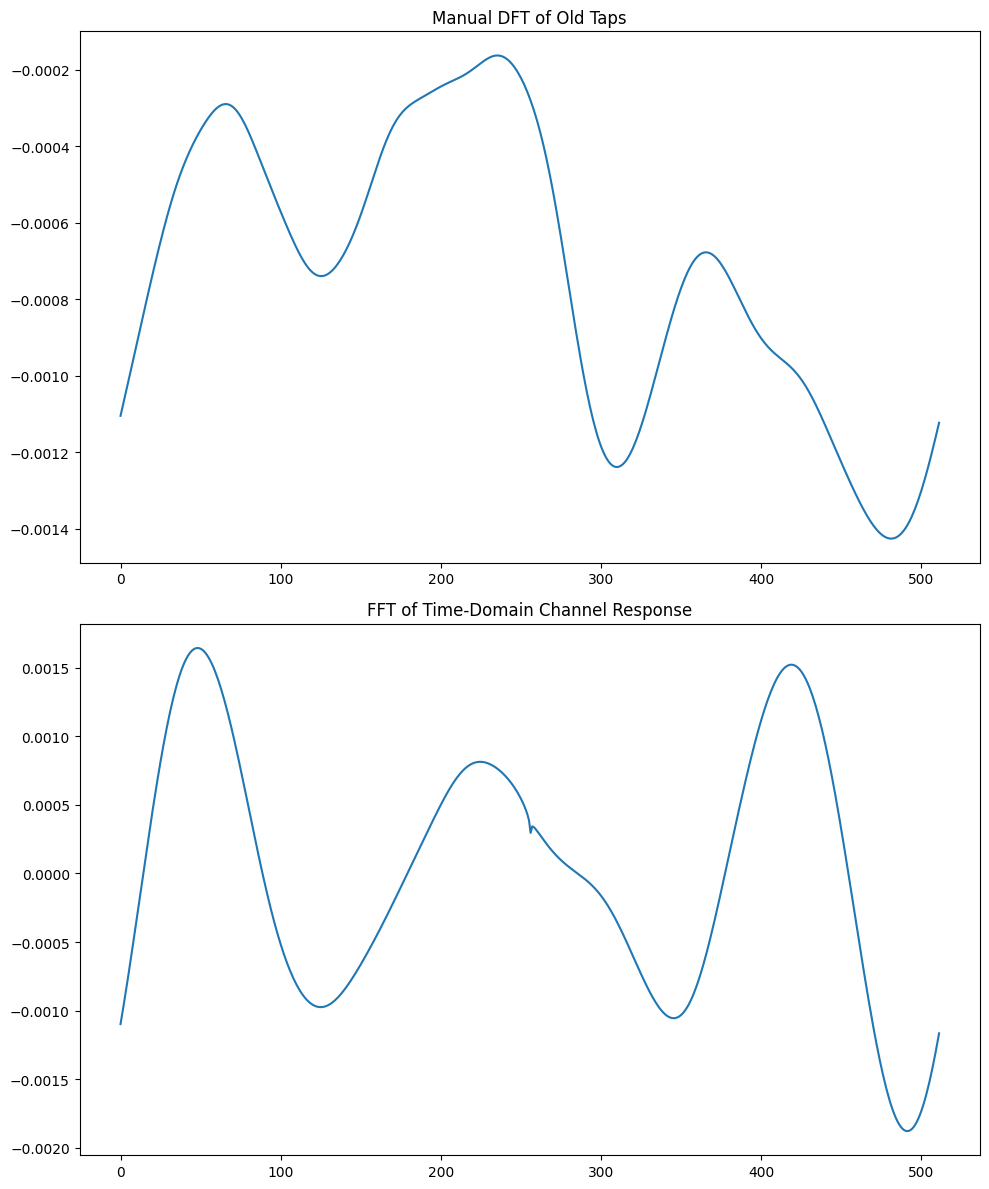

In [10]:
fft2 = np.zeros(fft_size, dtype=complex)
for i in range(len(a[RX_idx])):
    fft2 += a[RX_idx][i] * np.exp(-2j * np.pi * np.arange(fft_size) * i / fft_size)
h_time = np.zeros(fft_size, dtype=complex)
t_time = np.arange(fft_size) / B
for i in range(len(a[RX_idx])):
    h_time += a[RX_idx][i] * np.sinc((t_time - tau[RX_idx][i]) * B)
fft3 = np.fft.fft(h_time, n=fft_size)

fig, ax = plt.subplots(2, 1, figsize=(10, 12))

ax[0].plot(fft2)
ax[0].set_title('Manual DFT of Old Taps')

ax[1].plot(fft3)
ax[1].set_title('FFT of Time-Domain Channel Response')

plt.tight_layout()
plt.show()

Initial guess: [ 1.13933545e-03 -2.52809812e-04  3.46465402e-08  1.01748563e-03
  1.48360123e-04  2.43094265e-08  1.16815930e-03 -3.54122458e-05
  2.64978007e-08  1.13323017e-03 -1.89164653e-04  3.66863894e-08]
Estimated Taps: [0.00113934-2.52809812e-04j 0.00101749+1.48360123e-04j
 0.00116816-3.54122458e-05j 0.00113323-1.89164653e-04j]
Estimated Delays: [3.46465402e-08 2.43094265e-08 2.64978007e-08 3.85207088e-08]


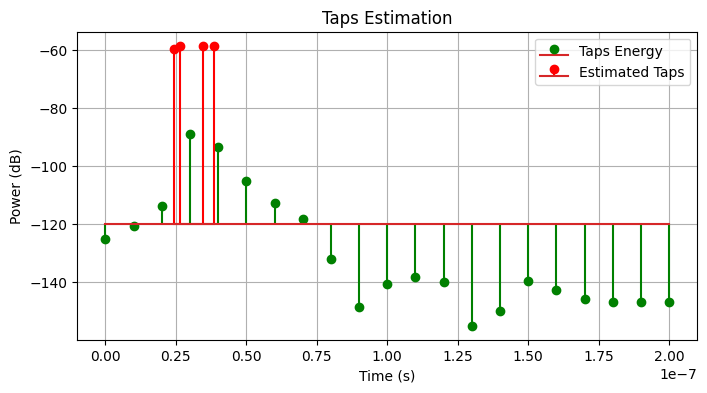

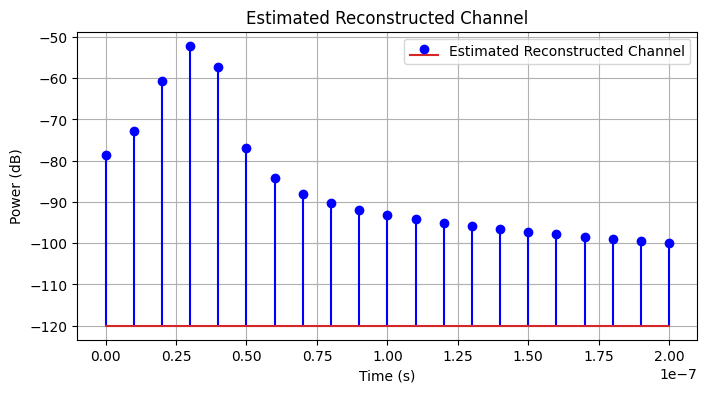

In [11]:
importlib.reload(mp)

RX_idx = 5
taps_lin_specific = taps_lin[RX_idx]
estimated_a, estimated_tau = mp.estimate_taps(taps_lin_specific, t, B, 4)

print("Estimated Taps:", estimated_a)
print("Estimated Delays:", estimated_tau)

plt.figure(figsize=(8, 4))
plt.stem(t, 10*np.log10(taps_energy[RX_idx]), bottom=10*np.log10(S_RX_lin), markerfmt='go', linefmt='g-', label='Taps Energy')
plt.stem(estimated_tau, 10*np.log10(np.abs(estimated_a)**2), bottom=10*np.log10(S_RX_lin), markerfmt='ro', linefmt='r-', label='Estimated Taps')
plt.xlabel('Time (s)')
plt.ylabel('Power (dB)')
plt.title('Taps Estimation')
plt.legend()
plt.grid(True)
plt.show()

estimated_reconstructed_channel = np.zeros(t.shape, dtype=complex)
for i in range(len(estimated_a)):
    estimated_reconstructed_channel += estimated_a[i] * np.sinc((t - estimated_tau[i]) * B)
plt.figure(figsize=(8, 4))
plt.stem(t, 10*np.log10(np.abs(estimated_reconstructed_channel)**2), bottom=10*np.log10(S_RX_lin), markerfmt='bo', linefmt='b-', label='Estimated Reconstructed Channel')
plt.xlabel('Time (s)')
plt.ylabel('Power (dB)')
plt.title('Estimated Reconstructed Channel')
plt.legend()
plt.grid(True)
plt.show()

Estimated position: [-5.36539754 -1.28832481]
True position: [[0, -2, 1.5]]
Estimated position (AoA): [ 2.16154633 -0.40612835]
True position: [[0, -2, 1.5]]
Received power at Rx8: -104.695709590794 dBm
Link budget for Rx8: -96.96917762553733 dB
Margin for Rx8: 7.726531965256669 dB
Angle of arrival at Rx8: 109.29010962637332 degrees


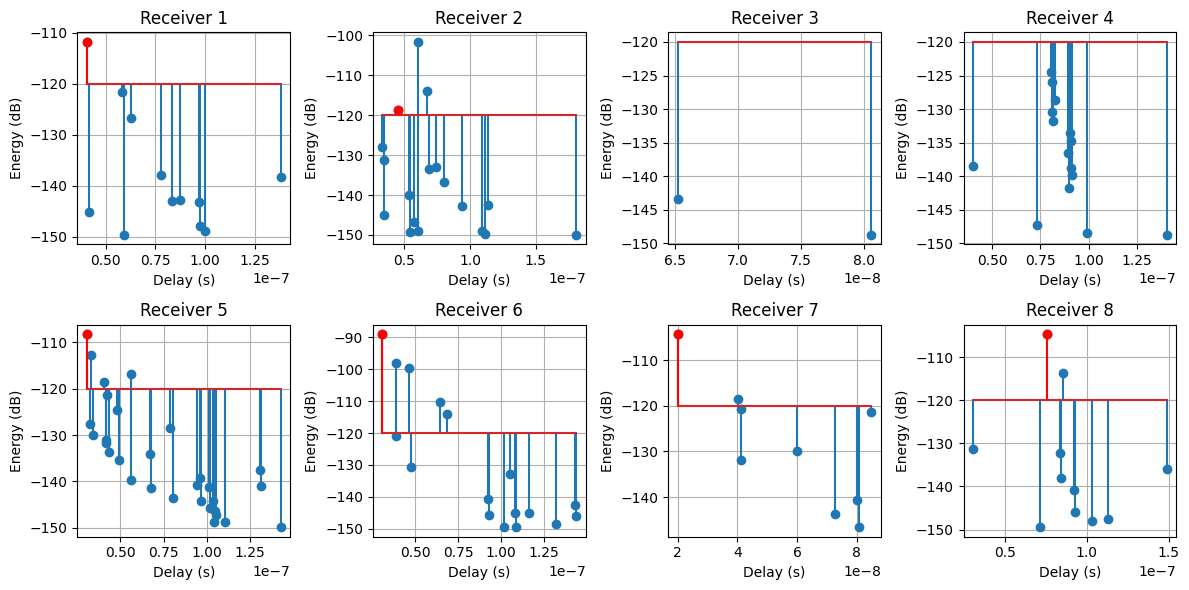

In [12]:
import Tdoa
import Aoa

importlib.reload(Tdoa)
importlib.reload(Aoa)
importlib.reload(util)

# Select TDOAs based on energy threshold

first_taps = -np.ones(8)
first_taps_mag = -np.ones(8)
first_taps_ang = 360 * np.ones(8)

for i in range(8):
    for j in range(len(energies[i])):
        if energies[i][j] >= S_RX_lin * 1e-0 and i in [0, 1, 2, 3, 4, 5, 6, 7]:
            first_taps[i] = tau[i][j]
            first_taps_mag[i] = energies[i][j]
            first_taps_ang[i] = angles[i][j]
            break


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i]), bottom=10*np.log10(S_RX_lin))
    if first_taps[i] >= 0:
        plt.stem(first_taps[i], 10*np.log10(first_taps_mag[i]), linefmt='r-', markerfmt='ro', bottom=10*np.log10(S_RX_lin))
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.grid()
plt.tight_layout()

TdoaLocalizer = Tdoa.TdoaLocalization(first_taps, RX_positions)
position_estimate = TdoaLocalizer.localize()
print("Estimated position:", position_estimate)
print("True position:", tx.position)

AoaLocalizer = Aoa.AoaLocalization(first_taps_ang, RX_positions)
position_estimate_aoa = AoaLocalizer.localize()
print("Estimated position (AoA):", position_estimate_aoa)
print("True position:", tx.position)

energy_received = first_taps_mag[7]
link_budget_dB = 10*np.log10(P_TX_lin) + 20*np.log10(1/(4*np.pi*first_taps[7]*3.5e9)) + 2*1.76
print(f"Received power at Rx8: {10*np.log10(energy_received)} dBm")
print(f"Link budget for Rx8: {link_budget_dB} dB")
print(f"Margin for Rx8: {link_budget_dB - 10*np.log10(energy_received)} dB")
print(f"Angle of arrival at Rx8: {first_taps_ang[7]*180/np.pi} degrees")
  

Estimated position: [-5.36539754 -1.28832481]
True position: [[0, -2, 1.5]]
Received power at Rx8: -104.695709590794 dBm
Link budget for Rx8: -96.96917762553733 dB
Margin for Rx8: 7.726531965256669 dB
Angle of arrival at Rx8: 109.29010962637332 degrees


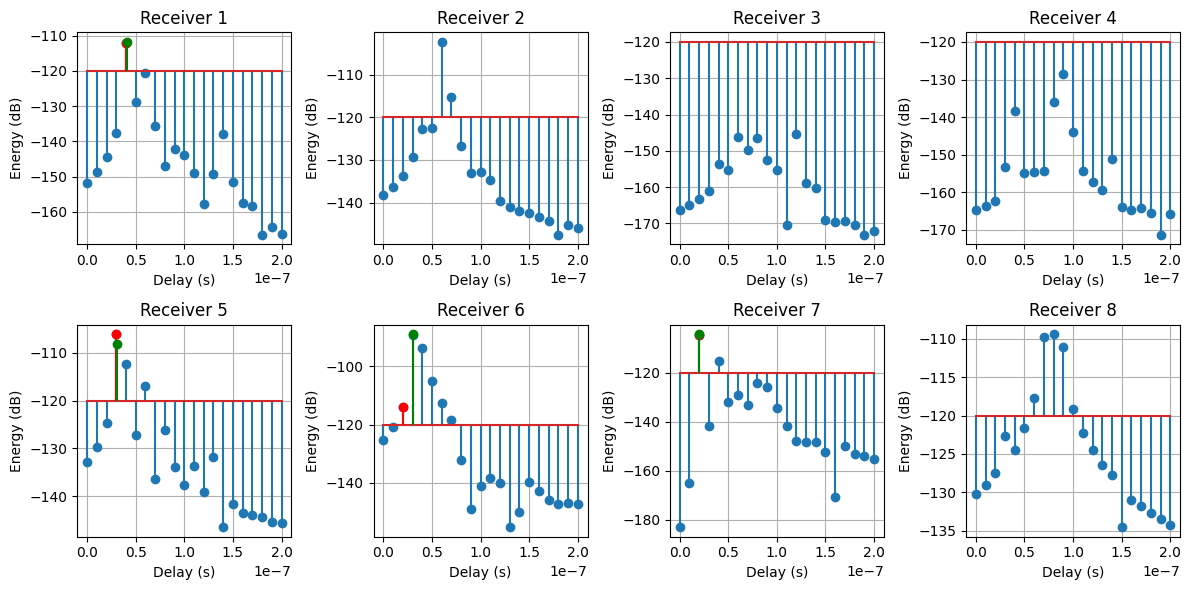

In [13]:
# Select TDOAs based on energy threshold

first_taps_2 = -np.ones(8)
first_taps_mag_2 = -np.ones(8)

for i in range(8):
    for j in range(len(taps_energy[i])):
        if taps_energy[i][j] >= S_RX_lin * 1e-0 and i in [0, 2, 3, 4, 5, 6]:
            first_taps_2[i] = t[j]
            first_taps_mag_2[i] = taps_energy[i][j]
            # first_taps_ang[i] = angles[i][j]
            break


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(t, 10*np.log10(taps_energy[i]), bottom=10*np.log10(S_RX_lin))
    if first_taps_2[i] >= 0:
        plt.stem(first_taps_2[i], 10*np.log10(first_taps_mag_2[i]), linefmt='r-', markerfmt='ro', bottom=10*np.log10(S_RX_lin))
        plt.stem(first_taps[i], 10*np.log10(first_taps_mag[i]), linefmt='g-', markerfmt='go', bottom=10*np.log10(S_RX_lin))
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.grid()
plt.tight_layout()

TdoaLocalizer = Tdoa.TdoaLocalization(first_taps, RX_positions)
position_estimate = TdoaLocalizer.localize()
print("Estimated position:", position_estimate)
print("True position:", tx.position)

energy_received = first_taps_mag[7]
link_budget_dB = 10*np.log10(P_TX_lin) + 20*np.log10(1/(4*np.pi*first_taps[7]*3.5e9)) + 2*1.76
print(f"Received power at Rx8: {10*np.log10(energy_received)} dBm")
print(f"Link budget for Rx8: {link_budget_dB} dB")
print(f"Margin for Rx8: {link_budget_dB - 10*np.log10(energy_received)} dB")
print(f"Angle of arrival at Rx8: {first_taps_ang[7]*180/np.pi} degrees")
  